In [70]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np

from nexuskan import *
from nexuskan import KAN
from nexuskan import nexusKAN

In [71]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# **KAN with interactions + FC** classification task

In [107]:
end_range = 1.0
start_range = 0.1
num_samples = 3000
x = (end_range - start_range) * torch.rand(num_samples + 200, 8) + start_range

norm_feature_1 = x[:, 0] / x[:, 1]
norm_feature_2 = x[:, 2] / x[:, 3]
norm_feature_3 = x[:, 4] / x[:, 5]
norm_feature_4 = x[:, 6] / x[:, 7]
 
feature_1 = (norm_feature_1 + norm_feature_2) / (norm_feature_3 + norm_feature_4)

# y = x[:, 2] / x[:, 0]
y_class = torch.where(feature_1 > 1.0, 1.0, 0.0)

dataset = {
    'train_input': x[:num_samples],
    'train_label': y_class[:num_samples].unsqueeze(dim=1),
    # 'train_label': y[:num_samples].unsqueeze(dim=1),
    
    'test_input': x[-200:],
    'test_label': y_class[-200:].unsqueeze(dim=1),
    # 'test_label': y[-200:].unsqueeze(dim=1),
}
dataset['train_input'] = dataset['train_input'].to(device)
dataset['train_label'] = dataset['train_label'].to(device)
dataset['test_input'] = dataset['test_input'].to(device)
dataset['test_label'] = dataset['test_label'].to(device)
print(dataset['train_input'].shape, dataset['train_label'].shape)
print(torch.unique(dataset['train_label'], return_counts=True))

torch.Size([3000, 8]) torch.Size([3000, 1])
(tensor([0., 1.], device='cuda:0'), tensor([1541, 1459], device='cuda:0'))


In [118]:
class InteractKANWithFC(nn.Module):
    def __init__(self, kan_width=[8, 4, 2, 1], output_dim=1):
        super(InteractKANWithFC, self).__init__()
        self.kan_width = kan_width.copy()
        self.kan1 = nexusKAN(width=kan_width, grid=5, k=3, seed=42, device=device)

        self.fc = nn.Linear(self.kan_width[-1], output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        x = self.kan1(x)
        x = self.fc(x)
        x = self.sigmoid(x)
        
        return x
    
    def fit_combined(self, train_input, train_label, test_input, test_label, 
                     epochs=600, lr=0.01, batch_size=32):

        optimizer = optim.Adam(self.parameters(), lr=lr)
        criterion = nn.BCELoss()
        
        train_losses = []
        test_losses = []
        
        for epoch in range(epochs):
            batches = train_input.shape[0] // batch_size
            for batch_idx in range(batches):
                if batch_idx == batches - 1:
                    indices = torch.arange(batch_idx * batch_size, train_input.shape[0])
                else:
                    indices = torch.arange(batch_idx * batch_size, (batch_idx + 1) * batch_size)
            
                batch_x = train_input[indices]
                batch_y = train_label[indices]
                
                if (epoch + 1) % 50 == 0:
                    for param_group in optimizer.param_groups:
                        param_group['lr'] *= 0.8
                
                outputs = self(batch_x)
                train_loss = criterion(outputs, batch_y)
                
                lamb = 0.00001
                l1_reg = sum(torch.norm(p, 1) for p in self.parameters())
                loss = train_loss + lamb * l1_reg
                
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            
            with torch.no_grad():
                test_outputs = self(test_input)
                test_loss = criterion(test_outputs, test_label)
                
            train_losses.append(loss.item())
            test_losses.append(test_loss.item())
            
            if (epoch + 1) % 10 == 0:
                print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss.item():.4f}, reg_loss: {loss.item():.4f} Test Loss: {test_loss.item():.4f}')
        
        return train_losses, test_losses


In [119]:
model = InteractKANWithFC(kan_width=[8, 4, 2, 1], output_dim=1)
model = model.to(device=device)

checkpoint directory created: ./model
saving model version 0.0


In [120]:
train_losses, test_losses = model.fit_combined(
    dataset['train_input'],
    dataset['train_label'],
    dataset['test_input'],
    dataset['test_label'],
    epochs=200,
    lr=0.1,
    batch_size=512
)

Epoch [10/200], Train Loss: 0.1004, reg_loss: 0.1049 Test Loss: 0.0951
Epoch [20/200], Train Loss: 0.0565, reg_loss: 0.0612 Test Loss: 0.1347
Epoch [30/200], Train Loss: 0.0768, reg_loss: 0.0818 Test Loss: 0.0971
Epoch [40/200], Train Loss: 0.0948, reg_loss: 0.1001 Test Loss: 0.1200
Epoch [50/200], Train Loss: 0.0964, reg_loss: 0.1018 Test Loss: 0.0986
Epoch [60/200], Train Loss: 0.0319, reg_loss: 0.0373 Test Loss: 0.0267
Epoch [70/200], Train Loss: 0.0466, reg_loss: 0.0520 Test Loss: 0.0341
Epoch [80/200], Train Loss: 0.0411, reg_loss: 0.0465 Test Loss: 0.0445
Epoch [90/200], Train Loss: 0.0256, reg_loss: 0.0310 Test Loss: 0.0574
Epoch [100/200], Train Loss: 0.0589, reg_loss: 0.0643 Test Loss: 0.1602
Epoch [110/200], Train Loss: 0.0277, reg_loss: 0.0331 Test Loss: 0.0655
Epoch [120/200], Train Loss: 0.0195, reg_loss: 0.0249 Test Loss: 0.0946
Epoch [130/200], Train Loss: 0.0146, reg_loss: 0.0201 Test Loss: 0.1328
Epoch [140/200], Train Loss: 0.0100, reg_loss: 0.0155 Test Loss: 0.1721
E

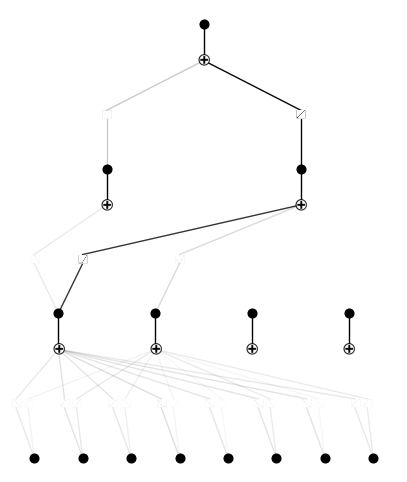

In [117]:
model.kan1.plot()